
### STEP 1 - Diagnostic Model Explainability

### Purpose

- This notebook examines how the best available churn model generated its predictions.

- Because the selected model demonstrated weak out-of-sample discrimination, explainability is used diagnostically rather than to make strong claims about churn drivers.

- The analysis includes:

- Global feature importance
- Permutation importance
- SHAP feature importance
- Individual prediction explanation
- Explainability limitations

### STEP 2 - Import Libraries

In [2]:
# Step 2a — Import Libraries

import os
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

import shap

# Define Paths
DATA_PROCESSED = os.path.join(
    "..",
    "data",
    "processed"
)

MODEL_DIR = os.path.join(
    "..",
    "models"
)

In [3]:
# step 2b - Load Model and Test Data
model_path = os.path.join(
    MODEL_DIR,
    "ridewise_xgboost_diagnostic_pipeline.pkl"
)

model = joblib.load(model_path)

X_test = pd.read_csv(
    os.path.join(
        DATA_PROCESSED,
        "ridewise_X_test.csv"
    )
)

y_test = pd.read_csv(
    os.path.join(
        DATA_PROCESSED,
        "ridewise_y_test.csv"
    )
).squeeze("columns")


In [4]:
# step 2c - Validate:

print("Test features:", X_test.shape)
print("Test target:", y_test.shape)


Test features: (1841, 29)
Test target: (1841,)


In [5]:
# step 2d - Confirm Model Performance

# Model performance is checked again before interpreting feature importance.

# Explainability should always be considered alongside predictive performance. A feature can be important to a weak model without being a reliable business driver.

y_test_probability = model.predict_proba(
    X_test
)[:, 1]

test_auc = roc_auc_score(
    y_test,
    y_test_probability
)

print(f"Test ROC-AUC: {test_auc:.4f}")

Test ROC-AUC: 0.5278


### Interpretation

- The test ROC-AUC remains close to 0.50.

- Therefore, the following explanations describe how the model formed its predictions, but they should not be interpreted as strong or causal churn drivers.

In [7]:
# step 2d(i) - Extract Pipeline Components
preprocessor = model.named_steps[
    "preprocessor"
]

classifier = model.named_steps[
    "classifier"
]

# Transform test data:

X_test_transformed = preprocessor.transform(
    X_test
)

print(
    "Transformed test shape:",
    X_test_transformed.shape
)


Transformed test shape: (1841, 39)


In [8]:
# step 2d(ii) - Get feature names:

feature_names = preprocessor.get_feature_names_out()

feature_names = [
    name.replace("num__", "")
        .replace("cat__", "")
    for name in feature_names
]

print(
    f"Number of transformed features: {len(feature_names)}"
)

Number of transformed features: 39


In [9]:
# step 2d(iii) - XGBoost Built-In Feature Importance

# XGBoost feature importance shows which transformed variables were used most frequently or strongly when building decision trees.

# This measures model reliance, not causation.

xgb_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": classifier.feature_importances_
})
xgb_importance = (
    xgb_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

xgb_importance.head(20)


,Feature,Importance
0,city_Lagos,0.041499
1,loyalty_status_Silver,0.036976
2,preferred_payment_Card,0.033967
3,account_age_days,0.033237
4,avg_surge_multiplier,0.032712
5,was_referred,0.032618
6,average_fare,0.032518
7,loyalty_status_Bronze,0.032483
8,rainy_trip_ratio,0.032477
9,trip_frequency_monthly,0.032465


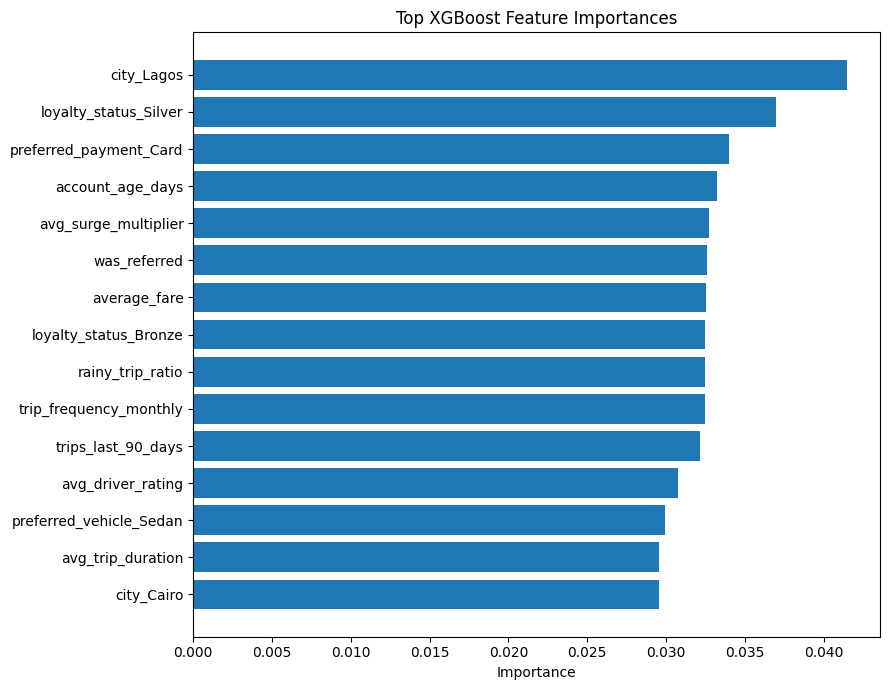

In [10]:
# step 2e - Visualize:

top_xgb_importance = (
    xgb_importance
    .head(15)
    .sort_values("Importance")
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_xgb_importance["Feature"],
    top_xgb_importance["Importance"]
)

ax.set_title(
    "Top XGBoost Feature Importances"
)

ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

### Interpretation

- The chart identifies the variables used most strongly by the fitted XGBoost model.

- However, because model discrimination was weak, high feature importance should not be interpreted as evidence that a feature reliably predicts or causes churn.

- A weak model can still assign importance to variables while failing to generalize accurately to unseen riders.

### STEP 3 - Permutation Importance

In [11]:
# step 3a - Permutation Importance

# Permutation importance measures the reduction in model performance after randomly shuffling one feature.

# If shuffling a feature causes little or no reduction in ROC-AUC, the model is not relying on that feature in a stable and useful way.

# Permutation importance is calculated on the unseen test set.

permutation_result = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create table:

permutation_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": permutation_result.importances_mean,

    "Importance Standard Deviation":
permutation_result.importances_std
})
permutation_df = (
    permutation_df
    .sort_values(
        "Importance Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_df.head(15)



,Feature,Importance Mean,Importance Standard Deviation
0,avg_driver_acceptance_rate,0.019630,0.013079
1,loyalty_status,0.013251,0.009217
2,avg_rating_given,0.011103,0.006835
3,recency_days,0.009491,0.008018
4,age,0.009396,0.009672
5,trip_frequency_monthly,0.008817,0.008523
6,account_age_days,0.007380,0.005960
7,avg_days_between_trips,0.002706,0.007617
8,trips_last_30_days,0.001673,0.001724
9,preferred_vehicle,0.001393,0.002383


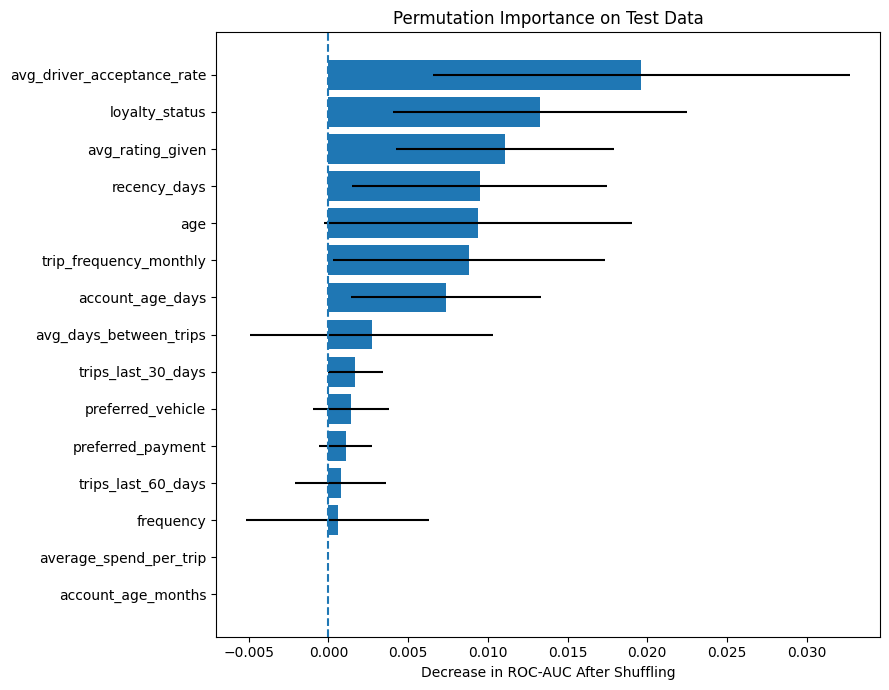

In [12]:
# step 3b - visualize

top_permutation = (
    permutation_df
    .head(15)
    .sort_values("Importance Mean")
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_permutation["Feature"],
    top_permutation["Importance Mean"],
    xerr=top_permutation[
        "Importance Standard Deviation"
    ]
)

ax.axvline(
    0,
    linestyle="--"
)

ax.set_title(
    "Permutation Importance on Test Data"
)

ax.set_xlabel(
    "Decrease in ROC-AUC After Shuffling"
)

plt.tight_layout()
plt.show()

### Interpretation

- Permutation importance provides a more cautious measure of practical feature usefulness.

- Features with values close to zero do not meaningfully affect test-set ROC-AUC when shuffled.

- Negative permutation values indicate that shuffling the feature occasionally improved performance, which may suggest noise, instability or overfitting.

- If most permutation importance values are close to zero, this supports the conclusion that no individual feature provides a strong and stable churn signal.

### STEP 4 -  Shap Analysis

In [13]:
# step 4a - Prepare SHAP Data


sample_size = min(
    500,
    X_test.shape[0]
)

sample_indices = X_test.sample(
    n=sample_size,
    random_state=42
).index

X_shap_original = X_test.loc[
    sample_indices
].copy()

X_shap_transformed = preprocessor.transform(
    X_shap_original
)

# Create a DataFrame:

X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=sample_indices
)

X_shap_df.head()


,account_age_days,age,avg_rating_given,was_referred,frequency,monetary_total,average_fare,recency_days,average_spend_per_trip,account_age_months,...,loyalty_status_Gold,loyalty_status_Platinum,loyalty_status_Silver,preferred_payment_Card,preferred_payment_Cash,preferred_payment_Mobile Money,preferred_vehicle_Luxury,preferred_vehicle_Motorcycle,preferred_vehicle_SUV,preferred_vehicle_Sedan
1557,-1.048626,-1.065182,0.089575,-0.654251,1.271588,0.338636,-1.691571,-0.742886,-1.691571,-1.048626,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1157,-0.776766,-0.539128,-0.611068,-0.654251,0.068960,0.403355,0.883858,-0.689439,0.883858,-0.776766,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
352,0.238860,1.565086,0.790217,1.528464,-0.171566,-0.092340,0.186475,-0.261863,0.186475,0.238860,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1018,-0.981943,0.512979,0.556670,1.528464,1.512113,1.694105,0.558404,-0.154969,0.558404,-0.981943,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1394,-0.068906,-0.223496,0.089575,-0.654251,-1.614720,-1.720180,-0.973892,0.860523,-0.973892,-0.068906,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [14]:
# step 4b - SHAP Analysis

# SHAP values estimate how each feature moved an individual model prediction higher or lower relative to the model's baseline prediction.

# SHAP explains model behaviour. It does not prove that changing a feature would change real-world churn behaviour.

explainer = shap.TreeExplainer(
    classifier
)

shap_values = explainer(
    X_shap_df
)

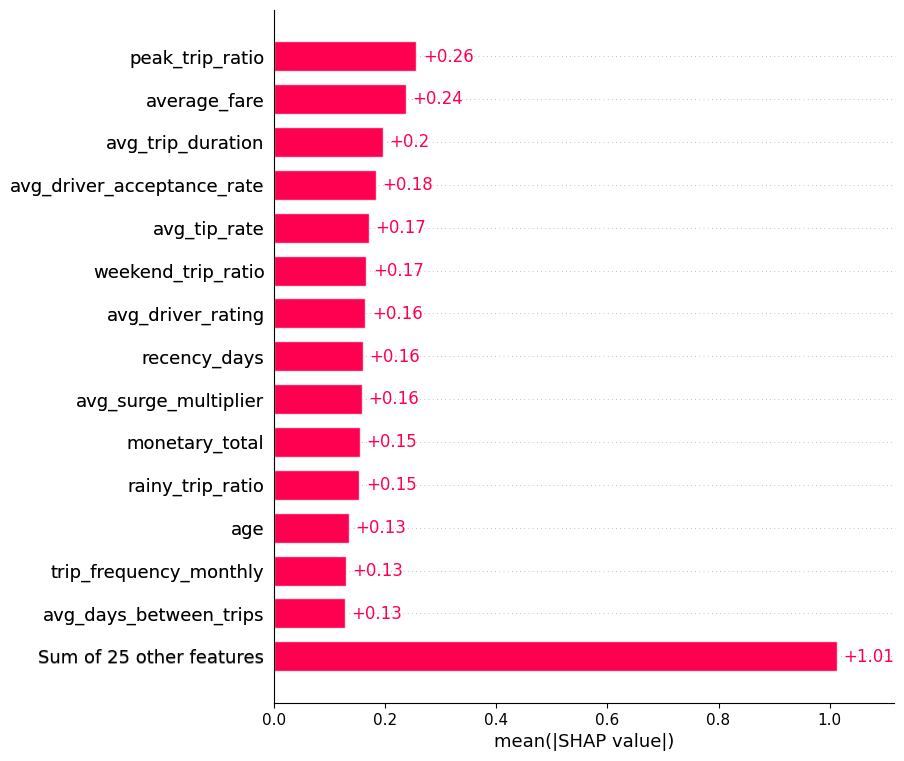

In [15]:
# step 4c - SHAP Global Importance
shap.plots.bar(
    shap_values,
    max_display=15
)



### SHAP Global Importance

- The SHAP bar plot ranks features according to their average absolute impact on model predictions.

- The ranking indicates which features most influenced the fitted XGBoost model across the sampled riders.

- Because the model had weak predictive performance, these rankings should be treated as diagnostic rather than definitive business evidence.

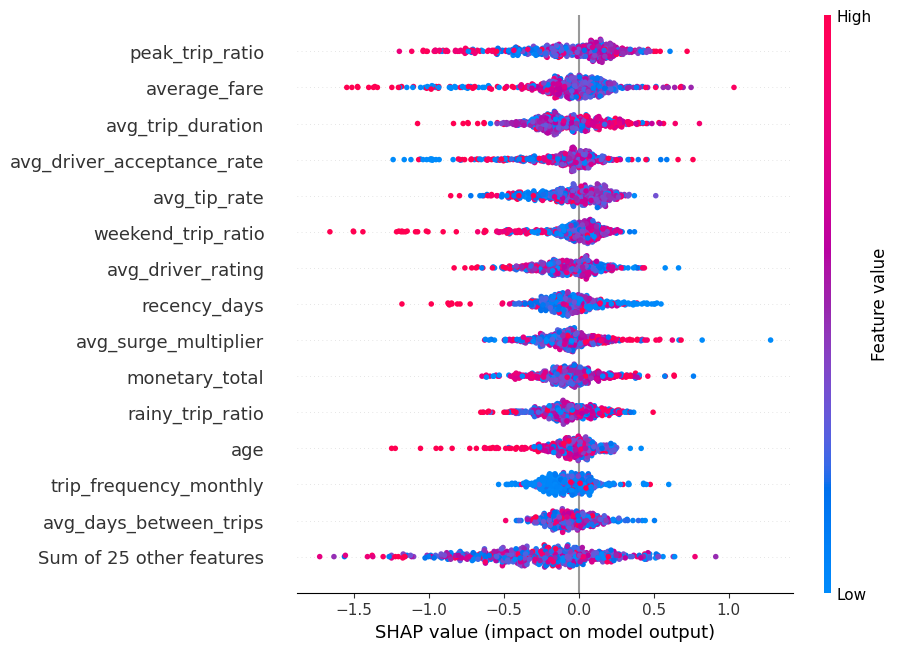

In [16]:
# step 4d - SHAP Summary Plot
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

### SHAP Summary Interpretation

Each point represents one rider.

- Features are ranked by overall impact.
- Points to the right increase the predicted churn probability.
- Points to the left decrease the predicted churn probability.
- Point colour represents whether the transformed feature value was relatively high or low.

In [18]:
# step 4e -  Explain One Individual Prediction

# elect the rider with the highest model probability in the SHAP sample:

sample_probabilities = classifier.predict_proba(
    X_shap_df
)[:, 1]

highest_risk_position = np.argmax(
    sample_probabilities
)

highest_risk_probability = (
    sample_probabilities[
        highest_risk_position
    ]
)

print(
    "Highest predicted churn probability:",
    round(highest_risk_probability, 3)
)


Highest predicted churn probability: 0.19


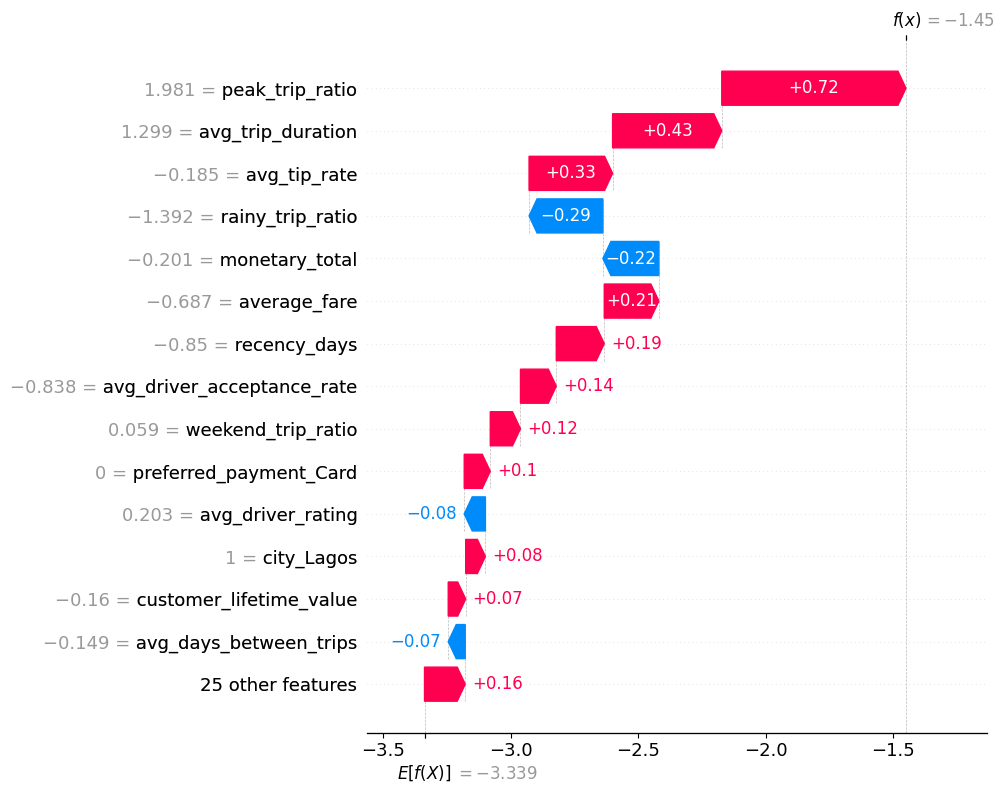

In [19]:
# step 4f - Waterfall plot:

shap.plots.waterfall(
    shap_values[
        highest_risk_position
    ],
    max_display=15
)

### Individual Prediction Interpretation

The waterfall plot shows how individual features moved this rider's prediction away from the model's baseline probability.

Features shown in one direction increased predicted churn risk, while features shown in the opposite direction reduced predicted risk.

This explanation describes the internal logic of the model for one rider. It should not be treated as a reliable retention recommendation because the overall model demonstrated weak discrimination.

In [20]:
# step 4g - Compare Feature-Importance Methods


print("Top Built-In XGBoost Features")

display(
    xgb_importance.head(10)
)

print("Top Permutation Features")

display(
    permutation_df.head(10)
)

Top Built-In XGBoost Features


,Feature,Importance
0,city_Lagos,0.041499
1,loyalty_status_Silver,0.036976
2,preferred_payment_Card,0.033967
3,account_age_days,0.033237
4,avg_surge_multiplier,0.032712
5,was_referred,0.032618
6,average_fare,0.032518
7,loyalty_status_Bronze,0.032483
8,rainy_trip_ratio,0.032477
9,trip_frequency_monthly,0.032465


Top Permutation Features


,Feature,Importance Mean,Importance Standard Deviation
0,avg_driver_acceptance_rate,0.019630,0.013079
1,loyalty_status,0.013251,0.009217
2,avg_rating_given,0.011103,0.006835
3,recency_days,0.009491,0.008018
4,age,0.009396,0.009672
5,trip_frequency_monthly,0.008817,0.008523
6,account_age_days,0.007380,0.005960
7,avg_days_between_trips,0.002706,0.007617
8,trips_last_30_days,0.001673,0.001724
9,preferred_vehicle,0.001393,0.002383



### Comparison of Importance Methods

Built-in XGBoost importance measures how the model used features while constructing trees.

Permutation importance measures how much test performance changes when each original feature is disrupted.

SHAP measures the direction and magnitude of feature contributions to individual predictions.

Differences between these rankings are expected because each method answers a different question.

Permutation importance is particularly important in this project because it evaluates whether features improve performance on unseen data.
Step 15 — Final Explainability Conclusion

Add this final markdown cell:

### Explainability Conclusion

The explainability analysis identified the features that the XGBoost model used most strongly when generating churn probabilities.

However, model explanations must be interpreted alongside predictive performance.

The selected model achieved ROC-AUC only slightly above random classification. Test-set permutation importance also indicated that no individual feature produced a large and stable improvement in discriminatory performance.

Therefore:

- Feature importance does not establish causation.
- SHAP values do not prove that the identified features are reliable churn drivers.
- Individual risk explanations should not be used for automated retention decisions.
- The model should not be deployed in its current form.

- The explainability analysis supports the broader modelling conclusion that the available synthetic data contains limited - historical information associated with future rider inactivity.

- The next project stage applies customer segmentation independently of the weak churn model. Segmentation will be used to understand 